In [1]:
import os
import copy
import torch
from pathlib import Path
from stCCL.stCCL.config import set_arg
from stCCL.stCCL.data import *
from stCCL.stCCL.utils import *
from stCCL.stCCL.stCCL import *
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score

In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
# path
data_root = Path('/home/ZHX/Dataset/DLPFC')
result_path = "/home/ZHX/code111/GraphST-main/final_result/stCCL_result/DLPFC_refined/"
# result_path = "/home/ZHX/code111/GraphST-main/results/MVInfoNCE2_result/DLPFC/no_refine/"
#设置参数
opt = set_arg()
arg = opt.parse_args(['--epoch','1000','--n_domain', '7'])
print(arg)

当前路径： /home/ZHX/code111/GraphST-main/stCCL/Tutorial
Namespace(epoch=1000, hvg_n=3000, knn=6, latent_dim=64, log_step=10, lr=0.001, n_domain=7, n_refine=25, radius=150, seed=0, temp=0.05, weight_decay=0.0001)


In [3]:
# slice_idx = ['151507', '151508', '151509', '151510',
#              '151669', '151670', '151671', '151672',
#              '151673', '151674', '151675', '151676']
slice_idx = ['151673']
# slice_idx = ['151676']
adata_list_raw=[]
adata_list_after_training=[]
adata_list_after_clustering = []
results = []

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


=============原始151673切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
=============预处理后151673切片信息===============
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'
spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (3639, 3000)
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances'

  0%|          | 1/1000 [00:00<02:59,  5.57it/s]

 epoch:  0  feat_loss = 1.00  loss_sl_1 = 10.80  loss_sl_2 = 0.06  total_loss = 3.18


 12%|█▏        | 118/1000 [00:01<00:10, 86.76it/s]

...

 80%|████████  | 805/1000 [00:10<00:04, 39.22it/s]

 epoch:  800  feat_loss = 0.14  loss_sl_1 = 0.06  loss_sl_2 = 0.01  total_loss = 0.16


 91%|█████████ | 906/1000 [00:12<00:02, 36.47it/s]

 epoch:  900  feat_loss = 0.14  loss_sl_1 = 0.05  loss_sl_2 = 0.01  total_loss = 0.15


100%|██████████| 1000/1000 [00:15<00:00, 65.58it/s]


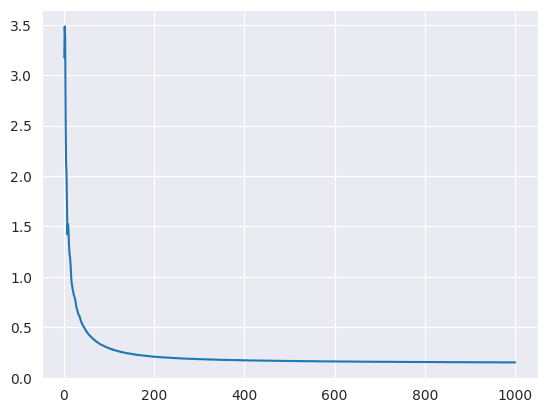

Completion of training


sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
ARI and NMI for slice 151673: 0.6309972207876174, 0.7380078998539996, 0.7585207391177207, 0.7185753133196501


/tmp/ipykernel_1634356/3181928122.py:44: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['ARI']=ARI


[{'slice_id': '151673', 'ARI': 0.6309972207876174, 'NMI': 0.7380078998539996, 'HS': 0.7585207391177207, 'CS': 0.7185753133196501}]


In [4]:


for sample_name in slice_idx:
    arg.n_domain = 5 if sample_name in ['151669', '151670', '151671', '151672'] else 7
    ## loading data
    adata = read_data(data_root, sample_name)

    ## add ground truth
    df_meta = pd.read_csv(data_root / sample_name / 'metadata.tsv', sep='\t')
    adata.obs['Ground Truth'] = df_meta['layer_guess']

    adata_list_raw.append(copy.deepcopy(adata)) ## 创建一个adata的深层副本并添加到列表中
    print("=============原始{}切片信息，带ground truth===============".format(sample_name))
    print(adata)

    #preprocessing
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=arg.hvg_n)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    print("=============预处理后{}切片信息===============".format(sample_name))
    print(adata)


    # train model
    adata = train(adata,arg)
    print("Completion of training")
    adata_list_after_training.append(adata)
    #
    #
    # clustering
    # adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' )
    # adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' ,refine=False)
    adata = mclust_R(adata, arg.n_domain,used_obsm='stCCL' ,refine=True)
#
    # filter out NA nodes
    adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
    ARI = adjusted_rand_score(adata.obs['mclust'], adata.obs['Ground Truth'])
    NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs['Ground Truth'])
    HS = homogeneity_score(adata.obs['Ground Truth'],adata.obs['mclust'])
    CS = completeness_score(adata.obs['Ground Truth'],adata.obs['mclust'])

    print(f"ARI and NMI for slice {sample_name}: {ARI}, {NMI}, {HS}, {CS}")
    results.append({'slice_id': sample_name, 'ARI': ARI, 'NMI': NMI, 'HS': HS,'CS': CS})
    # print('ARI = %.4f' %ARI)
    # result_ARI.append(ARI)
    adata.uns['ARI']=ARI
    adata.uns['NMI']=NMI
    adata.uns['HS']=HS
    adata.uns['CS']=CS

    adata_list_after_clustering.append(adata)
#
print(results)

#
# result_ARI.append(average_ARI)
# results_df = pd.DataFrame(result_ARI)
# results_df.to_csv(os.path.join(result_path,'MM_shared_MVInfoNCE_test1_DLPFC_ARI.csv'))


In [5]:
hvg_genes = adata.var_names[adata.var['highly_variable']].tolist()
print(f"高变基因数量: {len(hvg_genes)}")
print("前10个高变基因:", hvg_genes[:10])

# 2. 创建用于可视化的新AnnData对象
# 只包含高变基因，并添加原始和重建矩阵
hvg_adata = adata[:, hvg_genes].copy()

# 添加原始HVG表达矩阵
hvg_adata.layers['raw'] = adata.obsm['feat']  # 原始HVG表达

# 添加重建矩阵
hvg_adata.layers['stCCL'] = adata.obsm['stCCL']  # 去噪后表达

print(hvg_adata)

高变基因数量: 3000
前10个高变基因: ['HES4', 'VWA1', 'ATAD3B', 'AL645728.1', 'GABRD', 'PLCH2', 'HES5', 'TNFRSF14-AS1', 'CEP104', 'LINC01134']
AnnData object with n_obs × n_vars = 3611 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p', 'ARI', 'NMI', 'HS', 'CS'
    obsm: 'spatial', 'graph_neigh1', 'graph_neigh2', 'adj1', 'adj2', 'feat', 'feat_a', 'f_graph_neigh', 'fadj', 'latent', 'stCCL', 'emb_pca'
    layers: 'raw', 'stCCL'


In [6]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

# 确保 result_path 和 hvg_adata 已定义
out_path = os.path.join(result_path, hvg_adata.obs['slice_id'].unique()[0])

genes = ['ATP2B4', 'RASGRF2', 'LAMP5', 'NEFH', 'PCP4', 'B3GALT2']

for gene in genes:
    # --- 原始数据（Raw） ---
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    sc.pl.spatial(
        hvg_adata,
        img_key="hires",
        color=gene,
        layer='raw',
        cmap='viridis',
        vmax='p99',
        show=False,
        ax=ax,
        title="",          # 去除标题
        legend_loc='none'    # 去除图例（如果有）
    )
    # 手动移除 colorbar
    if ax.collections:
        cbar = ax.collections[-1].colorbar
        if cbar is not None:
            cbar.remove()
    ax.set_axis_off()        # 去除坐标轴
    plt.savefig(os.path.join(out_path, f"{gene}_raw.png"), bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    # --- stCCL 去噪后数据 ---
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    sc.pl.spatial(
        hvg_adata,
        img_key="hires",
        color=gene,
        layer='stCCL',
        cmap='viridis',
        vmax='p99',
        show=False,
        ax=ax,
        title="",
        legend_loc='none'
    )
    if ax.collections:
        cbar = ax.collections[-1].colorbar
        if cbar is not None:
            cbar.remove()
    ax.set_axis_off()
    plt.savefig(os.path.join(out_path, f"{gene}_stCCL.png"), bbox_inches='tight', pad_inches=0)
    plt.close(fig)

In [7]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

out_path = os.path.join(result_path, adata.obs['slice_id'].unique()[0])
# genes = ['ATP2B4', 'RASGRF2', 'LAMP5', 'NEFH', 'NTNG2', 'B3GALT2']
genes = ['ATP2B4', 'RASGRF2', 'LAMP5', 'NEFH', 'PCP4', 'B3GALT2']

out_path = os.path.join(result_path, hvg_adata.obs['slice_id'].unique()[0])  # 假设hvg_adata有slice_id

for gene in genes:
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    sc.pl.spatial(hvg_adata, img_key="hires", color=gene, layer='raw', cmap='viridis', show=False, ax=axs[0], title=f'Raw: {gene}', vmax='p99')
    sc.pl.spatial(hvg_adata, img_key="hires", color=gene, layer='stCCL', cmap='viridis', show=False, ax=axs[1], title=f'stCCL: {gene}', vmax='p99')
    plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"), bbox_inches='tight')
    plt.close(fig)  # 关闭图形释放内存

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


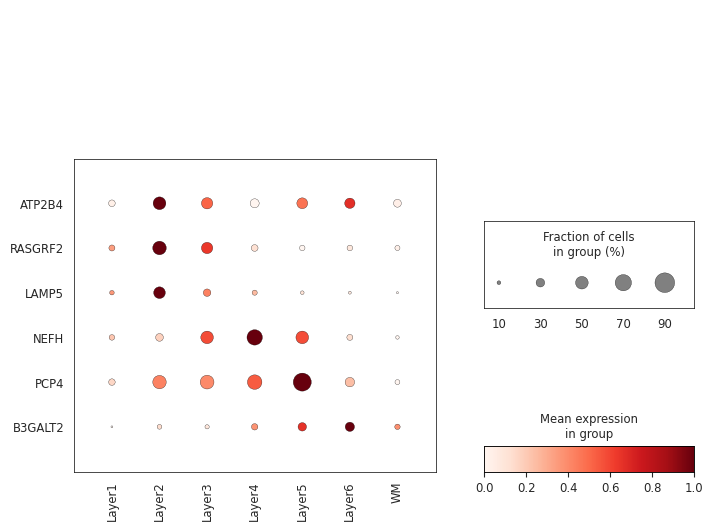

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


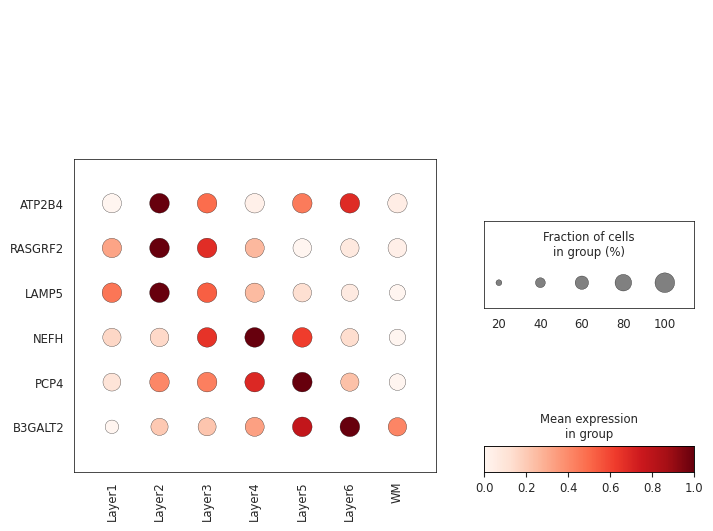

去噪前点图已保存至: /home/ZHX/code111/GraphST-main/final_result/stCCL_result/DLPFC_refined/151673/dotplot_raw.png
去噪后点图已保存至: /home/ZHX/code111/GraphST-main/final_result/stCCL_result/DLPFC_refined/151673/dotplot_stccl.png


In [8]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

out_path = os.path.join(result_path, adata.obs['slice_id'].unique()[0])

def customize_figure(fig):
    """强制设置背景白色和主图边框"""
    # 1. 图与所有轴背景白色
    fig.patch.set_facecolor('white')
    for ax in fig.get_axes():
        ax.set_facecolor('white')
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(0.5)

# 基因列表（可按需调整）
genes = ['ATP2B4', 'RASGRF2', 'LAMP5', 'NEFH', 'PCP4', 'B3GALT2']

# ---------- 去噪前 (raw) ----------
fig1, ax1 = plt.subplots(figsize=(8, 6))
sc.pl.dotplot(
    hvg_adata,
    var_names=genes,
    groupby='Ground Truth',
    layer='raw',
    standard_scale='var',
    swap_axes=True,
    ax=ax1,
    show=False
)
customize_figure(fig1)
# ax1.set_title('Raw')
ax1.set_xlabel('Raw')
plt.savefig(os.path.join(out_path, 'dotplot_raw.png'),
            dpi=300, bbox_inches='tight', pad_inches=0.2,
            facecolor='white')   # 显式指定保存背景色
plt.show()
plt.close(fig1)

# ---------- 去噪后 (stCCL) ----------
fig2, ax2 = plt.subplots(figsize=(8, 6))
sc.pl.dotplot(
    hvg_adata,
    var_names=genes,
    groupby='Ground Truth',
    layer='stCCL',
    standard_scale='var',
    swap_axes=True,
    ax=ax2,
    show=False
)
customize_figure(fig2)
# ax2.set_title('stCCL')
ax2.set_xlabel('stCCL')
plt.savefig(os.path.join(out_path, 'dotplot_stccl.png'),
            dpi=300, bbox_inches='tight', pad_inches=0.2,
            facecolor='white')
plt.show()
plt.close(fig2)

print("去噪前点图已保存至:", os.path.join(out_path, 'dotplot_raw.png'))
print("去噪后点图已保存至:", os.path.join(out_path, 'dotplot_stccl.png'))

In [9]:
print(adata)

AnnData object with n_obs × n_vars = 3611 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_id', 'Ground Truth', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p', 'ARI', 'NMI', 'HS', 'CS'
    obsm: 'spatial', 'graph_neigh1', 'graph_neigh2', 'adj1', 'adj2', 'feat', 'feat_a', 'f_graph_neigh', 'fadj', 'latent', 'stCCL', 'emb_pca'


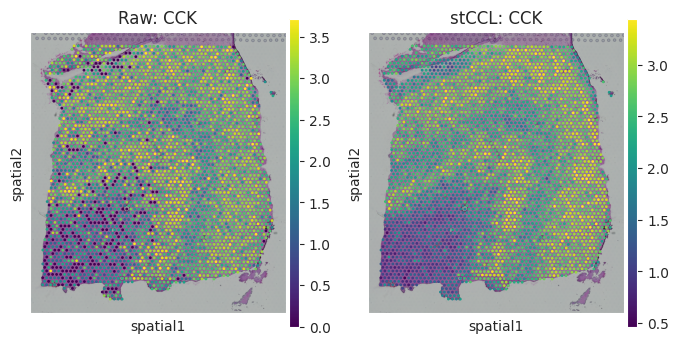

In [10]:
# # # plotting spatial clustering result
out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])

gene ='CCK'

# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.spatial(adata,img_key="hires",color=gene,show=False,title=f'Raw: {gene}',vmax='p99')
# plt.savefig(os.path.join(out_path, f"{gene}_adata.X.png"))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

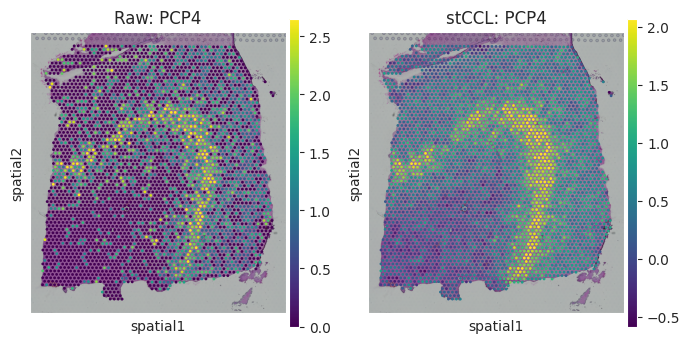

In [11]:
# # # plotting spatial clustering result
out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])

gene ='PCP4'

# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.spatial(adata,img_key="hires",color=gene,show=False,title=f'Raw: {gene}',vmax='p99')
# plt.savefig(os.path.join(out_path, f"{gene}_adata.X.png"))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))


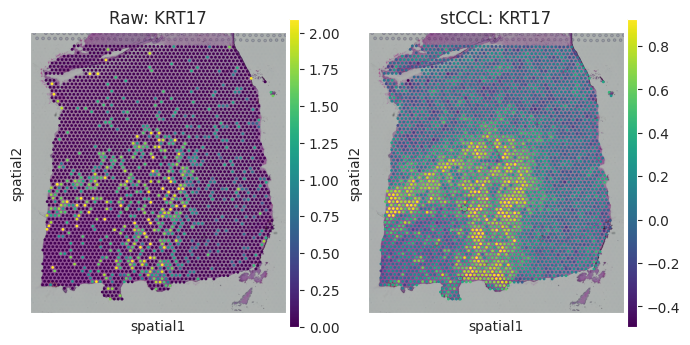

In [12]:
# # # plotting spatial clustering result
out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])

gene ='KRT17'

# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.spatial(adata,img_key="hires",color=gene,show=False,title=f'Raw: {gene}',vmax='p99')
# plt.savefig(os.path.join(out_path, f"{gene}_adata.X.png"))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))


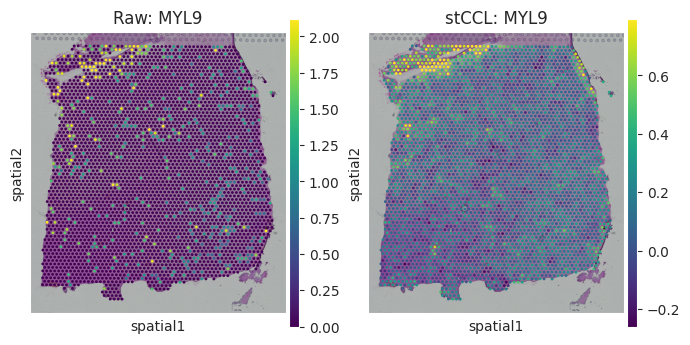

In [13]:
# # # plotting spatial clustering result
out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])

gene ='MYL9'

# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.spatial(adata,img_key="hires",color=gene,show=False,title=f'Raw: {gene}',vmax='p99')
# plt.savefig(os.path.join(out_path, f"{gene}_adata.X.png"))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

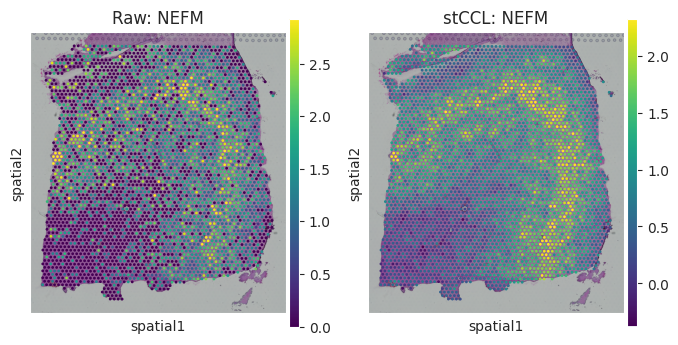

In [14]:
# # # plotting spatial clustering result
out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])

gene ='NEFM'

# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.spatial(adata,img_key="hires",color=gene,show=False,title=f'Raw: {gene}',vmax='p99')
# plt.savefig(os.path.join(out_path, f"{gene}_adata.X.png"))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

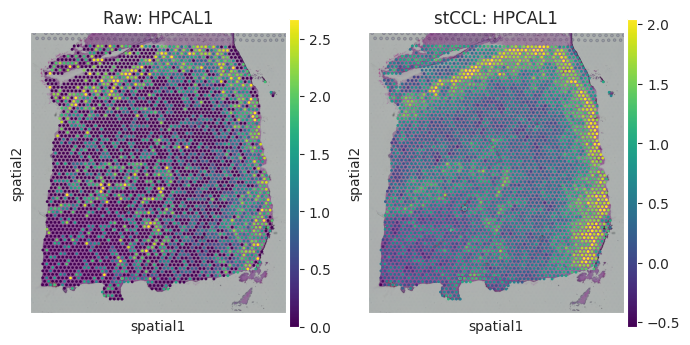

In [15]:
# # # plotting spatial clustering result
out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])

gene ='HPCAL1'

# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.spatial(adata,img_key="hires",color=gene,show=False,title=f'Raw: {gene}',vmax='p99')
# plt.savefig(os.path.join(out_path, f"{gene}_adata.X.png"))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

参考STAGATE

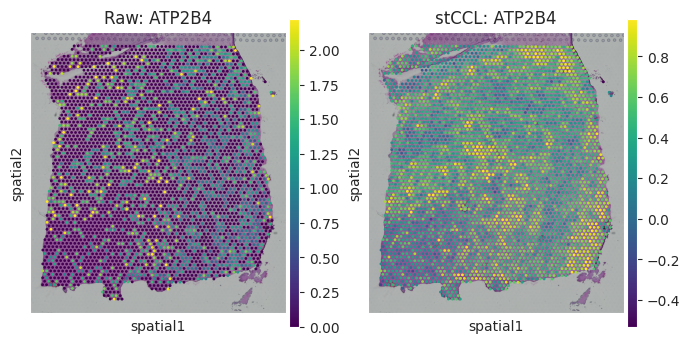

In [16]:
# # # plotting spatial clustering result
out_path = os.path.join(result_path , adata.obs['slice_id'].unique()[0])

gene ='ATP2B4'

# plt.rcParams["figure.figsize"] = (5, 5)
# sc.pl.spatial(adata,img_key="hires",color=gene,show=False,title=f'Raw: {gene}',vmax='p99')
# plt.savefig(os.path.join(out_path, f"{gene}_adata.X.png"))

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

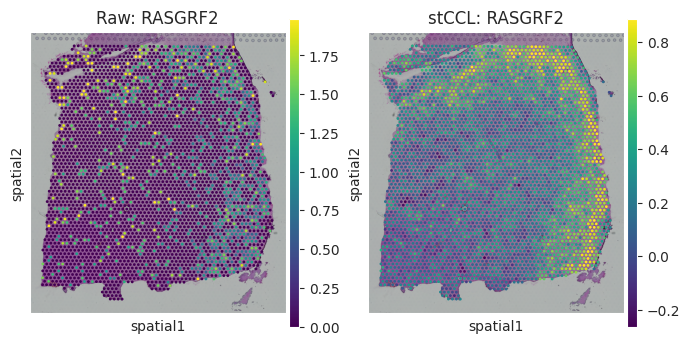

In [17]:
gene ='RASGRF2'
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

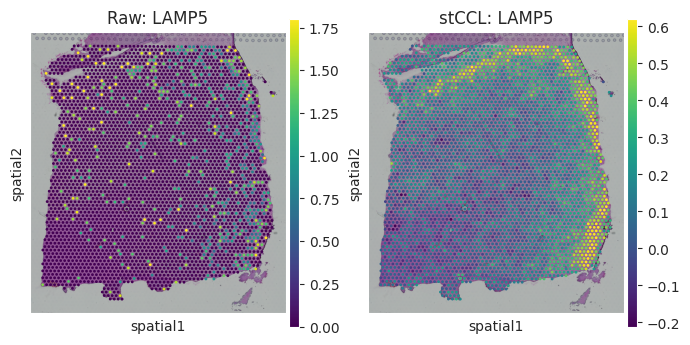

In [18]:
gene ='LAMP5'
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

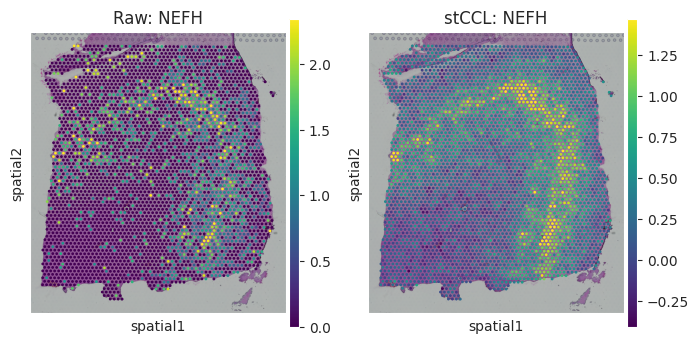

In [19]:
gene ='NEFH'
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

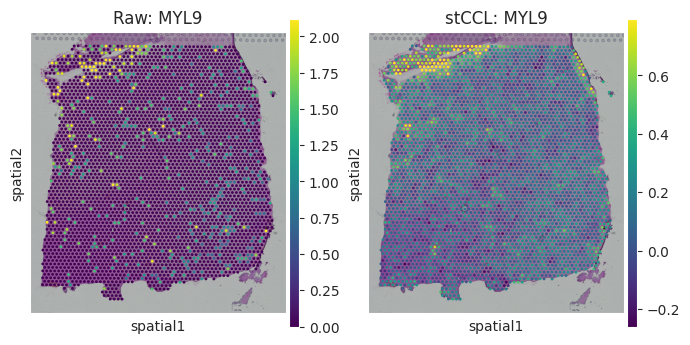

In [20]:
#NTNG2基因不在151673切片的hvg中
# gene ='NTNG2'
# gene ='KRT17'
gene ='MYL9'
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

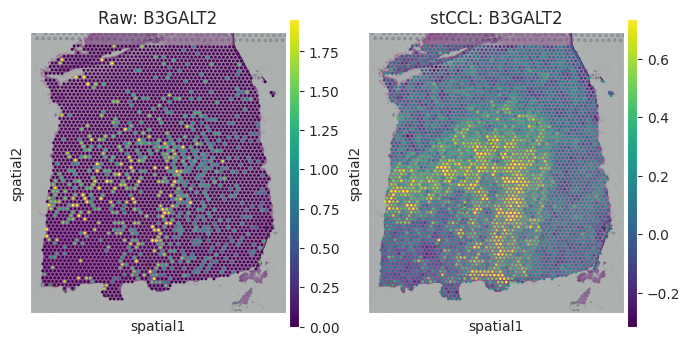

In [21]:
gene ='B3GALT2'
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))

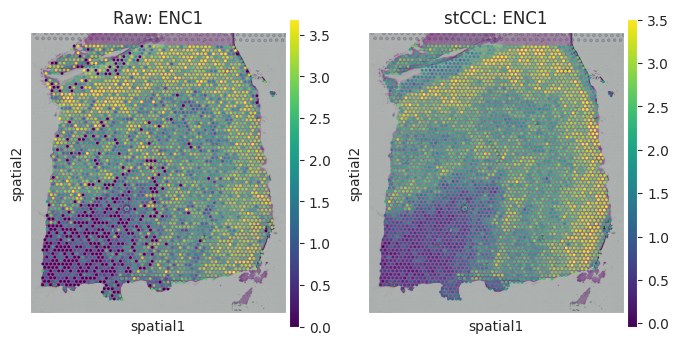

In [22]:
gene ='ENC1'
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# 原始表达
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='raw', cmap='viridis',show=False,ax=axs[0],title=f'Raw: {gene}',vmax='p99')
sc.pl.spatial(hvg_adata,img_key="hires",color=gene,layer='stCCL', cmap='viridis',show=False,ax=axs[1],title=f'stCCL: {gene}',vmax='p99')
plt.savefig(os.path.join(out_path, f"{gene}_denoising.png"))